# Centros Federales 

Este cuaderno analiza y compara los **centros penitenciarios federales** de México,
clasificados según su tipo de administración: **Privado (CPS)** y **Público**.

Se utilizan datos del Cuaderno Mensual de Información Estadística Penitenciaria Nacional 2026
para explorar las dimensiones de:
- Población e infraestructura
- Incidencias y seguridad
- Ingresos y egresos
- Escolaridad de la población interna
- Distribución por grupos de edad

### Librerías e importaciones

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
pd.set_option('display.max_columns', None)

## 1. Carga y procesamiento de datos

### 1.1 Población

Se carga el archivo de población mensual por centro. Se calcula el **promedio** de población
para cada centro a lo largo del periodo disponible, ya que los datos tienen una observación por mes.
Posteriormente se clasifica cada centro como **Privado (CPS)** o **Público** según si contiene
la sigla "CPS" en su nombre.

In [3]:
población= pd.read_csv('Cuaderno Mensual de Información Estadística Penitenciaria Nacional /2026/poblacion_mensual_detalle.csv')
población.head()

,Mes,Centro,Espacios,Sobrepoblacion_Absoluta,Sobrepoblacion_Relativa_Pct,Fuero_Comun_Subtotal,Fuero_Federal_Subtotal,Poblacion_Total
0,Enero 2026,CEFERESO No. 1 Altiplano,844,-223,-26.42,68,553,621
1,Enero 2026,CEFERESO No. 4 Noroeste,2350,-114,-4.85,1356,880,2236
2,Enero 2026,CEFERESO No. 5 Oriente,3078,-1701,-55.26,764,613,1377
3,Enero 2026,CEFERESO No. 7 Nor-Noroeste,480,-169,-35.21,155,156,311
4,Enero 2026,CEFERESO No. 8 Nor-Poniente,812,-178,-21.92,214,420,634


In [4]:
población.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Mes                          60 non-null     object 
 1   Centro                       60 non-null     object 
 2   Espacios                     60 non-null     int64  
 3   Sobrepoblacion_Absoluta      60 non-null     int64  
 4   Sobrepoblacion_Relativa_Pct  60 non-null     float64
 5   Fuero_Comun_Subtotal         60 non-null     int64  
 6   Fuero_Federal_Subtotal       60 non-null     int64  
 7   Poblacion_Total              60 non-null     int64  
dtypes: float64(1), int64(5), object(2)
memory usage: 3.9+ KB


In [5]:
población_promedio= población.groupby('Centro').agg(
    Espacios=('Espacios','first'),
    Promedio_población=('Poblacion_Total', 'mean'),
    Población_min=('Poblacion_Total','min'),
    Población_max=('Poblacion_Total','max'),
    Pct_Sobre_relativa_promedio=('Sobrepoblacion_Relativa_Pct','mean')
).reset_index()
población_promedio

,Centro,Espacios,Promedio_población,Población_min,Población_max,Pct_Sobre_relativa_promedio
0,CEFEREPSI,460,157.25,153,163,-65.8175
1,CEFERESO No. 1 Altiplano,844,615.75,595,628,-27.0425
2,CEFERESO No. 11 CPS Sonora,2520,2261.75,2221,2283,-10.2475
3,CEFERESO No. 12 CPS Guanajuato,2520,2180.00,2161,2197,-13.4950
4,CEFERESO No. 13 CPS Oaxaca,2520,2074.25,2065,2079,-17.6900
5,CEFERESO No. 14 CPS Durango,2520,2258.50,2246,2268,-10.3775
6,CEFERESO No. 15 CPS Chiapas,2520,1775.75,1762,1792,-29.5325
7,CEFERESO No. 16 CPS Femenil Morelos,2528,662.25,651,677,-73.8025
8,CEFERESO No. 17 CPS Michoacán,2520,1969.00,1920,2057,-21.8650
9,CEFERESO No. 18 CPS Coahuila,2528,2010.75,1978,2026,-20.4625


In [6]:
población_promedio.loc[:, 'Tipo'] = población_promedio['Centro'].apply(lambda x: 'Privado (CPS)' if 'CPS' in x else 'Publico')

In [7]:
población_promedio = población_promedio[población_promedio['Centro'] != 'CENTROS PENITENCIARIOS FEDERALES (subtotal)']
población_promedio

,Centro,Espacios,Promedio_población,Población_min,Población_max,Pct_Sobre_relativa_promedio,Tipo
0,CEFEREPSI,460,157.25,153,163,-65.8175,Publico
1,CEFERESO No. 1 Altiplano,844,615.75,595,628,-27.0425,Publico
2,CEFERESO No. 11 CPS Sonora,2520,2261.75,2221,2283,-10.2475,Privado (CPS)
3,CEFERESO No. 12 CPS Guanajuato,2520,2180.00,2161,2197,-13.4950,Privado (CPS)
4,CEFERESO No. 13 CPS Oaxaca,2520,2074.25,2065,2079,-17.6900,Privado (CPS)
5,CEFERESO No. 14 CPS Durango,2520,2258.50,2246,2268,-10.3775,Privado (CPS)
6,CEFERESO No. 15 CPS Chiapas,2520,1775.75,1762,1792,-29.5325,Privado (CPS)
7,CEFERESO No. 16 CPS Femenil Morelos,2528,662.25,651,677,-73.8025,Privado (CPS)
8,CEFERESO No. 17 CPS Michoacán,2520,1969.00,1920,2057,-21.8650,Privado (CPS)
9,CEFERESO No. 18 CPS Coahuila,2528,2010.75,1978,2026,-20.4625,Privado (CPS)


In [8]:
población_federal = población_promedio.groupby('Tipo').agg(
    n_centros=('Centro','count'), 
    espacios=('Espacios','sum'),
    poblacion_total=('Promedio_población','sum'))
población_federal['porcentaje_ocupación']= población_federal['poblacion_total']/población_federal['espacios']
población_federal= población_federal.reset_index()

### 1.2 Incidencias

Se carga el archivo de incidencias en centros federales. Los datos se agregan a dos niveles:
- **Por tipo e incidencia:** para analizar qué categoría de incidencia ocurre más
- **Por tipo:** para integrar al DataFrame general `federales`

La **tasa de incidencia x1000** se calcula dividiendo el número de incidencias
entre la población total y multiplicando por 1,000, lo que permite comparar
centros de distinto tamaño de forma justa.

In [9]:
incidencias= pd.read_csv('Cuaderno Mensual de Información Estadística Penitenciaria Nacional /2026/incidencias_centros_federales_2026_ancho_compacto.csv')
incidencias

,mes,centro,tipo,incidencia,incidencias,personas_involucradas,personas_heridas
0,2026-01,CEFEREPSI,Publico,Agresiones a Terceros,5.0,5.0,0.0
1,2026-01,CEFERESO No. 1 Altiplano,Publico,Agresiones a Terceros,4.0,4.0,0.0
2,2026-01,CEFERESO No. 14 CPS Durango,Privado (CPS),Agresiones a Terceros,2.0,3.0,0.0
3,2026-01,CEFERESO No. 15 CPS Chiapas,Privado (CPS),Agresiones a Terceros,2.0,17.0,0.0
4,2026-01,CEFERESO No. 17 CPS Michoacan,Privado (CPS),Agresiones a Terceros,7.0,23.0,0.0
...,...,...,...,...,...,...,...
65,2026-04,CEFERESO No. 11 CPS Sonora,Privado (CPS),Riñas,1.0,2.0,0.0
66,2026-04,CEFERESO No. 5 Oriente,Publico,Riñas,1.0,2.0,1.0
67,2026-04,CEFERESO No. 13 CPS Oaxaca,Privado (CPS),Suicidios,1.0,1.0,0.0
68,2026-04,CEFERESO No. 16 CPS Femenil Morelos,Privado (CPS),Suicidios,1.0,1.0,0.0


In [10]:
tipo_incidencias=incidencias.groupby(['tipo','incidencia']).agg(
    incidencias=('incidencias','sum'),
    personas_involucradas=('personas_involucradas','sum'),
    personas_heridas=('personas_heridas','sum')
).reset_index()
tipo_incidencias

,tipo,incidencia,incidencias,personas_involucradas,personas_heridas
0,Privado (CPS),Agresiones a Terceros,21.0,74.0,0.0
1,Privado (CPS),Autoagresiones,6.0,6.0,0.0
2,Privado (CPS),Decesos por muerte natural o enfermedad,12.0,12.0,0.0
3,Privado (CPS),Intentos de Homicidio,1.0,1.0,0.0
4,Privado (CPS),Intentos de Suicidio,1.0,1.0,0.0
5,Privado (CPS),Riñas,21.0,57.0,20.0
6,Privado (CPS),Suicidios,5.0,5.0,0.0
7,Publico,Agresiones a Terceros,16.0,19.0,0.0
8,Publico,Autoagresiones,8.0,8.0,0.0
9,Publico,Decesos por muerte natural o enfermedad,4.0,4.0,0.0


In [11]:
incidencias_federales= incidencias.groupby('tipo').agg(
    n_incidencias=('incidencias','sum'),
    personas_involucradas=('personas_involucradas','sum'), 
    personas_heridas=('personas_heridas','sum'))
incidencias_federales= incidencias_federales.reset_index()

In [12]:
incidencias_federales = incidencias_federales.rename(columns={'tipo': 'Tipo'})

In [13]:
print(población_federal.columns.tolist())
print(incidencias_federales.columns.tolist())


['Tipo', 'n_centros', 'espacios', 'poblacion_total', 'porcentaje_ocupación']
['Tipo', 'n_incidencias', 'personas_involucradas', 'personas_heridas']


In [14]:
federales= pd.merge(población_federal,incidencias_federales, on='Tipo', how='inner')
federales

,Tipo,n_centros,espacios,poblacion_total,porcentaje_ocupación,n_incidencias,personas_involucradas,personas_heridas
0,Privado (CPS),8,20176,15192.25,0.752986,67.0,156.0,20.0
1,Publico,6,8024,5466.00,0.681206,46.0,64.0,4.0


In [15]:
federales ['tasa_incidencia_x1000 ']= (federales['n_incidencias']/federales['poblacion_total'])*1000
federales

,Tipo,n_centros,espacios,poblacion_total,porcentaje_ocupación,n_incidencias,personas_involucradas,personas_heridas,tasa_incidencia_x1000
0,Privado (CPS),8,20176,15192.25,0.752986,67.0,156.0,20.0,4.410143
1,Publico,6,8024,5466.00,0.681206,46.0,64.0,4.0,8.415660


### 1.3 Ingresos y egresos

Se carga el archivo de movimiento de personas (ingresos y egresos) por centro.
Se agregan por tipo de centro para obtener el flujo total de cada categoría.

In [16]:
ingresos_egresos= pd.read_csv('Cuaderno Mensual de Información Estadística Penitenciaria Nacional /2026/ingresos_egresos_centros_federales_2026.csv')
ingresos_egresos.head()

,mes,centro,tipo,ingresos_total,egresos_total
0,2026-01,CEFEREPSI,Publico,0,1
1,2026-01,CEFERESO No. 1 Altiplano,Publico,21,12
2,2026-01,CEFERESO No. 11 CPS Sonora,Privado (CPS),36,26
3,2026-01,CEFERESO No. 12 CPS Guanajuato,Privado (CPS),41,30
4,2026-01,CEFERESO No. 13 CPS Oaxaca,Privado (CPS),42,24


In [17]:
ingresos_egresos_centro= ingresos_egresos.groupby('centro').agg(
    Ingresos=('ingresos_total','sum'),
    Egresos=('egresos_total','sum'),
    Tipo=('tipo','first')
).reset_index()
ingresos_egresos_centro

,centro,Ingresos,Egresos,Tipo
0,CEFEREPSI,11,2,Publico
1,CEFERESO No. 1 Altiplano,77,61,Publico
2,CEFERESO No. 11 CPS Sonora,128,180,Privado (CPS)
3,CEFERESO No. 12 CPS Guanajuato,183,136,Privado (CPS)
4,CEFERESO No. 13 CPS Oaxaca,149,128,Privado (CPS)
5,CEFERESO No. 14 CPS Durango,11,41,Privado (CPS)
6,CEFERESO No. 15 CPS Chiapas,44,53,Privado (CPS)
7,CEFERESO No. 16 CPS Femenil Morelos,28,50,Privado (CPS)
8,CEFERESO No. 17 CPS Michoacan,328,115,Privado (CPS)
9,CEFERESO No. 18 CPS Coahuila,166,134,Privado (CPS)


In [18]:
ingresos_egresos_federales= ingresos_egresos_centro.groupby('Tipo').agg(
    Ingresos=('Ingresos','sum'),
    Egresos=('Egresos','sum')
).reset_index()
ingresos_egresos_federales

,Tipo,Ingresos,Egresos
0,Privado (CPS),1037,837
1,Publico,637,410


In [19]:
federales= pd.merge(federales,ingresos_egresos_federales, on='Tipo', how='inner')
federales

,Tipo,n_centros,espacios,poblacion_total,porcentaje_ocupación,n_incidencias,personas_involucradas,personas_heridas,tasa_incidencia_x1000,Ingresos,Egresos
0,Privado (CPS),8,20176,15192.25,0.752986,67.0,156.0,20.0,4.410143,1037,837
1,Publico,6,8024,5466.00,0.681206,46.0,64.0,4.0,8.415660,637,410


### 1.4 Escolaridad

Se carga el archivo de escolaridad de la población interna. Como los datos tienen
una observación por mes, se calcula el **promedio por centro** y luego se agregan
por tipo de administración. Incluye 16 niveles educativos, desde analfabetismo
hasta doctorado completo.
Se elimino el nivel preescolar del análisis porque no tenía datos.

In [20]:
escolaridad= pd.read_csv('Cuaderno Mensual de Información Estadística Penitenciaria Nacional /2026/escolaridad_centros_federales_2026.csv')
escolaridad.head()

,mes,centro,tipo,no_sabe_leer_escribir,sabe_leer_escribir,preescolar_incompleta,preescolar_completa,primaria_incompleta,primaria_completa,secundaria_incompleta,secundaria_completa,bachillerato_incompleto,bachillerato_completo,carrera_tecnica_incompleta,carrera_tecnica_completa,licenciatura_incompleta,licenciatura_completa,maestria_incompleta,maestria_completa,doctorado_incompleto,doctorado_completo,total
0,2026-01,CEFEREPSI,Publico,0,9,0,0,27,19,8,50,14,16,1,1,4,3,0,1,0,0,153
1,2026-01,CEFERESO No. 1 Altiplano,Publico,0,4,0,0,23,43,53,172,88,116,1,5,37,60,2,14,1,2,621
2,2026-01,CEFERESO No. 11 CPS Sonora,Privado (CPS),19,46,0,0,159,265,211,927,304,209,13,24,69,36,1,0,0,0,2283
3,2026-01,CEFERESO No. 12 CPS Guanajuato,Privado (CPS),22,9,0,0,88,334,191,1044,175,169,0,12,32,72,10,3,0,0,2161
4,2026-01,CEFERESO No. 13 CPS Oaxaca,Privado (CPS),26,70,0,0,100,300,166,860,191,210,1,30,55,56,3,7,0,1,2076


In [21]:
escolaridad['preescolar_completa'].value_counts()

preescolar_completa
0    56
Name: count, dtype: int64

In [22]:
escolaridad_centro= escolaridad.groupby('centro').agg(
    no_sabe_leer_escribir =('no_sabe_leer_escribir','mean'),
    sabe_leer_escribir=('sabe_leer_escribir','mean'),
    primaria_incompleta=('primaria_incompleta','mean'),
    primaria_completa=('primaria_completa','mean'),
    secundaria_incompleta=('secundaria_incompleta','mean'),
    secundaria_completa=('secundaria_completa','mean'),
    bachillerato_incompleto=('bachillerato_incompleto','mean'),
    bachillerato_completo=('bachillerato_completo', 'mean'),
    carrera_tecnica_incompleta=('carrera_tecnica_incompleta','mean'),
    carrera_tecnica_completa=('carrera_tecnica_completa','mean'),
    licenciatura_incompleta=('licenciatura_incompleta','mean'),
    licenciatura_completa=('licenciatura_completa','mean'),
    maestria_incompleta=('maestria_incompleta','mean'),
    maestria_completa=('maestria_completa','mean'),
    doctorado_incompleto=('doctorado_incompleto','mean'),
    doctorado_completo=('doctorado_completo','mean'),
    Tipo=('tipo','first')
).reset_index()
escolaridad_centro

,centro,no_sabe_leer_escribir,sabe_leer_escribir,primaria_incompleta,primaria_completa,secundaria_incompleta,secundaria_completa,bachillerato_incompleto,bachillerato_completo,carrera_tecnica_incompleta,carrera_tecnica_completa,licenciatura_incompleta,licenciatura_completa,maestria_incompleta,maestria_completa,doctorado_incompleto,doctorado_completo,Tipo
0,CEFEREPSI,0.00,7.75,27.00,21.25,8.50,52.00,14.00,16.00,1.00,1.00,4.75,3.00,0.00,1.00,0.00,0.0,Publico
1,CEFERESO No. 1 Altiplano,0.00,4.00,18.50,40.75,43.75,176.50,90.75,103.25,1.00,5.00,38.50,74.75,2.00,14.00,1.00,2.0,Publico
2,CEFERESO No. 11 CPS Sonora,19.00,44.75,157.50,251.25,209.00,934.25,295.00,209.75,13.00,23.75,68.00,35.50,1.00,0.00,0.00,0.0,Privado (CPS)
3,CEFERESO No. 12 CPS Guanajuato,22.00,7.00,87.25,334.00,195.25,1054.00,175.00,169.00,0.00,12.00,36.00,70.25,12.25,6.00,0.00,0.0,Privado (CPS)
4,CEFERESO No. 13 CPS Oaxaca,26.50,65.75,100.00,298.75,169.00,860.25,190.75,209.75,1.00,30.00,55.00,56.50,3.00,7.00,0.00,1.0,Privado (CPS)
5,CEFERESO No. 14 CPS Durango,3.00,12.00,62.25,81.00,131.75,354.75,603.25,769.00,0.00,0.00,173.50,66.00,2.00,0.00,0.00,0.0,Privado (CPS)
6,CEFERESO No. 15 CPS Chiapas,65.00,0.00,126.00,233.25,190.25,537.50,264.00,169.50,0.00,27.50,93.00,54.50,0.00,13.25,1.00,1.0,Privado (CPS)
7,CEFERESO No. 16 CPS Femenil Morelos,1.75,0.50,8.25,8.50,19.00,255.75,150.75,119.00,2.00,18.25,37.50,32.50,3.75,4.75,0.00,0.0,Privado (CPS)
8,CEFERESO No. 17 CPS Michoacan,0.00,889.50,113.00,98.75,177.00,433.50,182.25,11.00,0.00,4.00,21.00,39.00,0.00,0.00,0.00,0.0,Privado (CPS)
9,CEFERESO No. 18 CPS Coahuila,0.00,34.00,144.50,246.75,188.75,645.00,186.25,262.75,75.75,61.50,84.25,64.25,11.00,6.00,0.00,0.0,Privado (CPS)


In [23]:
escolaridad_federal= escolaridad_centro.groupby('Tipo').agg(
    no_sabe_leer_escribir =('no_sabe_leer_escribir','sum'),
    sabe_leer_escribir=('sabe_leer_escribir','sum'),
    primaria_incompleta=('primaria_incompleta','sum'),
    primaria_completa=('primaria_completa','sum'),
    secundaria_incompleta=('secundaria_incompleta','sum'),
    secundaria_completa=('secundaria_completa','sum'),
    bachillerato_incompleto=('bachillerato_incompleto','sum'),
    bachillerato_completo=('bachillerato_completo', 'sum'),
    carrera_tecnica_incompleta=('carrera_tecnica_incompleta','sum'),
    carrera_tecnica_completa=('carrera_tecnica_completa','sum'),
    licenciatura_incompleta=('licenciatura_incompleta','sum'),
    licenciatura_completa=('licenciatura_completa','sum'),
    maestria_incompleta=('maestria_incompleta','sum'),
    maestria_completa=('maestria_completa','sum'),
    doctorado_incompleto=('doctorado_incompleto','sum'),
    doctorado_completo=('doctorado_completo','sum')
).reset_index()
escolaridad_federal

,Tipo,no_sabe_leer_escribir,sabe_leer_escribir,primaria_incompleta,primaria_completa,secundaria_incompleta,secundaria_completa,bachillerato_incompleto,bachillerato_completo,carrera_tecnica_incompleta,carrera_tecnica_completa,licenciatura_incompleta,licenciatura_completa,maestria_incompleta,maestria_completa,doctorado_incompleto,doctorado_completo
0,Privado (CPS),137.25,1053.5,798.75,1552.25,1280.00,5075.0,2047.25,1919.75,91.75,177.00,568.25,418.5,33.00,37.00,1.00,2.0
1,Publico,29.00,78.5,389.50,478.75,464.25,1636.0,1076.25,830.25,3.00,17.75,190.00,245.0,5.25,17.75,1.75,3.0


### 1.5 Grupos de edad

Se carga el archivo de distribución de edad de la población interna,
organizada en grupos quinquenales de los 18 a los 60+ años.

In [24]:
edades= pd.read_csv('Cuaderno Mensual de Información Estadística Penitenciaria Nacional /2026/edades_centros_federales_2026.csv')
edades.head()

,mes,centro,tipo,18-24,25-29,30-34,35-39,40-44,45-49,50-54,55-59,60+,total
0,2026-01,CEFEREPSI,Publico,2,8,27,27,23,17,22,17,10,153
1,2026-01,CEFERESO No. 1 Altiplano,Publico,18,42,85,91,102,96,75,45,67,621
2,2026-01,CEFERESO No. 11 CPS Sonora,Privado (CPS),375,353,353,377,265,230,153,129,48,2283
3,2026-01,CEFERESO No. 12 CPS Guanajuato,Privado (CPS),172,292,428,413,330,245,134,82,65,2161
4,2026-01,CEFERESO No. 13 CPS Oaxaca,Privado (CPS),66,249,415,427,343,260,146,89,81,2076


In [25]:
edades_centro = edades.groupby('centro').agg({
    'tipo': 'first',
    '18-24': 'mean',
    '25-29': 'mean',
    '30-34': 'mean',
    '35-39': 'mean',
    '40-44': 'mean',
    '45-49': 'mean',
    '50-54': 'mean',
    '55-59': 'mean',
    '60+': 'mean'
}).reset_index()
edades_centro

,centro,tipo,18-24,25-29,30-34,35-39,40-44,45-49,50-54,55-59,60+
0,CEFEREPSI,Publico,2.00,8.75,28.25,28.00,23.25,17.25,22.00,17.00,10.75
1,CEFERESO No. 1 Altiplano,Publico,17.50,39.25,82.00,90.75,101.50,96.00,75.25,44.75,68.75
2,CEFERESO No. 11 CPS Sonora,Privado (CPS),375.00,346.00,354.25,361.75,264.50,231.25,151.00,130.00,48.00
3,CEFERESO No. 12 CPS Guanajuato,Privado (CPS),171.75,303.00,428.00,416.25,336.50,242.25,136.50,80.50,65.25
4,CEFERESO No. 13 CPS Oaxaca,Privado (CPS),72.00,245.50,407.75,425.75,341.25,256.75,153.75,90.00,81.50
5,CEFERESO No. 14 CPS Durango,Privado (CPS),43.25,146.75,402.75,497.75,436.75,315.50,202.00,130.25,83.50
6,CEFERESO No. 15 CPS Chiapas,Privado (CPS),45.75,194.25,355.00,372.75,336.75,228.00,113.00,78.50,51.75
7,CEFERESO No. 16 CPS Femenil Morelos,Privado (CPS),18.50,52.25,139.50,138.75,102.75,82.75,56.50,33.25,38.00
8,CEFERESO No. 17 CPS Michoacan,Privado (CPS),127.75,238.50,358.25,373.75,361.50,206.50,164.25,83.75,54.75
9,CEFERESO No. 18 CPS Coahuila,Privado (CPS),57.75,234.00,406.00,441.50,359.25,225.75,151.50,72.50,62.50


In [26]:
edades_federales= edades_centro.groupby('tipo').agg({
    '18-24': 'sum',
    '25-29': 'sum',
    '30-34': 'sum',
    '35-39': 'sum',
    '40-44': 'sum',
    '45-49': 'sum',
    '50-54': 'sum',
    '55-59': 'sum',
    '60+': 'sum'
}).reset_index()
edades_federales

,tipo,18-24,25-29,30-34,35-39,40-44,45-49,50-54,55-59,60+
0,Privado (CPS),911.75,1760.25,2851.5,3028.25,2539.25,1788.75,1128.50,698.75,485.25
1,Publico,273.25,541.75,1029.0,1021.75,882.00,698.50,498.25,286.00,235.50


In [27]:
edades_federales= edades_federales.rename(columns={'tipo':'Tipo'})
edades_federales

,Tipo,18-24,25-29,30-34,35-39,40-44,45-49,50-54,55-59,60+
0,Privado (CPS),911.75,1760.25,2851.5,3028.25,2539.25,1788.75,1128.50,698.75,485.25
1,Publico,273.25,541.75,1029.0,1021.75,882.00,698.50,498.25,286.00,235.50


### 1.6 Origen y fuero (enero 2026)

Se carga información sobre el fuero (común o federal) y condición jurídica
(procesado o sentenciado) de la población, cruzada con su entidad de origen.
Se construyen columnas totales combinando hombres y mujeres porque solo hay un centro federal femenil, el resto son centros varoniles.

In [28]:
general_enero= pd.read_csv('Cuaderno Mensual de Información Estadística Penitenciaria Nacional /2026/origen_fuero_centros_federales_enero_2026.csv')
general_enero

,mes,mes_nombre,centro,tipo,entidad_origen,fc_procesados_h,fc_procesados_m,fc_sentenciados_h,fc_sentenciados_m,ff_procesados_h,ff_procesados_m,ff_sentenciados_h,ff_sentenciados_m,total
0,2026-01,Enero 2026,CEFERESO No. 1 Altiplano,Publico,Aguascalientes,0,0,0,0,0,0,0,0,0
1,2026-01,Enero 2026,CEFERESO No. 1 Altiplano,Publico,Baja California,0,0,1,0,12,0,2,0,15
2,2026-01,Enero 2026,CEFERESO No. 1 Altiplano,Publico,Baja California Sur,0,0,0,0,0,0,0,0,0
3,2026-01,Enero 2026,CEFERESO No. 1 Altiplano,Publico,Campeche,0,0,0,0,2,0,0,0,2
4,2026-01,Enero 2026,CEFERESO No. 1 Altiplano,Publico,Chiapas,0,0,1,0,5,0,1,0,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1843,2026-04,Abril 2026,CEFEREPSI,Publico,Tlaxcala,1,0,1,0,1,0,0,0,3
1844,2026-04,Abril 2026,CEFEREPSI,Publico,Veracruz de Ignacio de la Llave,1,0,5,0,0,0,2,0,8
1845,2026-04,Abril 2026,CEFEREPSI,Publico,Yucatán,0,0,0,0,0,0,0,0,0
1846,2026-04,Abril 2026,CEFEREPSI,Publico,Zacatecas,0,0,5,0,0,0,0,0,5


In [29]:
general_enero['fc_procesados'] = general_enero['fc_procesados_h'] + general_enero['fc_procesados_m']
general_enero['fc_sentenciados'] = general_enero['fc_sentenciados_h'] + general_enero['fc_sentenciados_m']
general_enero['ff_procesados'] = general_enero['ff_procesados_h'] + general_enero['ff_procesados_m']
general_enero['ff_sentenciados'] = general_enero['ff_sentenciados_h'] + general_enero['ff_sentenciados_m']

In [30]:
resumen_general = general_enero.groupby(['centro', 'entidad_origen']).agg(
    tipo=('tipo', 'first'),
    fc_procesados=('fc_procesados', 'sum'),
    fc_sentenciados=('fc_sentenciados', 'sum'),
    ff_procesados=('ff_procesados', 'sum'),
    ff_sentenciados=('ff_sentenciados', 'sum'),
    total=('total', 'sum')
).reset_index()

resumen_general

,centro,entidad_origen,tipo,fc_procesados,fc_sentenciados,ff_procesados,ff_sentenciados,total
0,CEFEREPSI,Aguascalientes,Publico,0,8,0,0,8
1,CEFEREPSI,Baja California,Publico,0,4,0,0,4
2,CEFEREPSI,Baja California Sur,Publico,0,4,0,2,6
3,CEFEREPSI,Campeche,Publico,0,0,0,4,4
4,CEFEREPSI,Chiapas,Publico,8,36,0,1,45
...,...,...,...,...,...,...,...,...
457,CEFERESO No. 8 Nor-Poniente,Tamaulipas,Publico,0,4,0,26,30
458,CEFERESO No. 8 Nor-Poniente,Tlaxcala,Publico,0,0,0,0,0
459,CEFERESO No. 8 Nor-Poniente,Veracruz de Ignacio de la Llave,Publico,0,4,17,7,28
460,CEFERESO No. 8 Nor-Poniente,Yucatán,Publico,0,0,0,0,0


## 2. Visualización

### 2.1 Métricas generales por tipo de centro

Comparación de las principales métricas operativas entre centros Privados (CPS) y Públicos.
Los valores son absolutos, por lo que diferencias en tamaño afectan la comparación.
La métrica más relevante para comparar es la **tasa de incidencia x1000**, que normaliza
por el tamaño de la población. Sin embargo, no hay información suficiete para declarar que por cada 1000 personas existen ese número de incidencias, ya que no estan ligadas a las personas privadas de su libertad, por lo que es solamente para comparar los centros públicos y privados con datos normalizados.

In [31]:
federales.columns = federales.columns.str.strip()

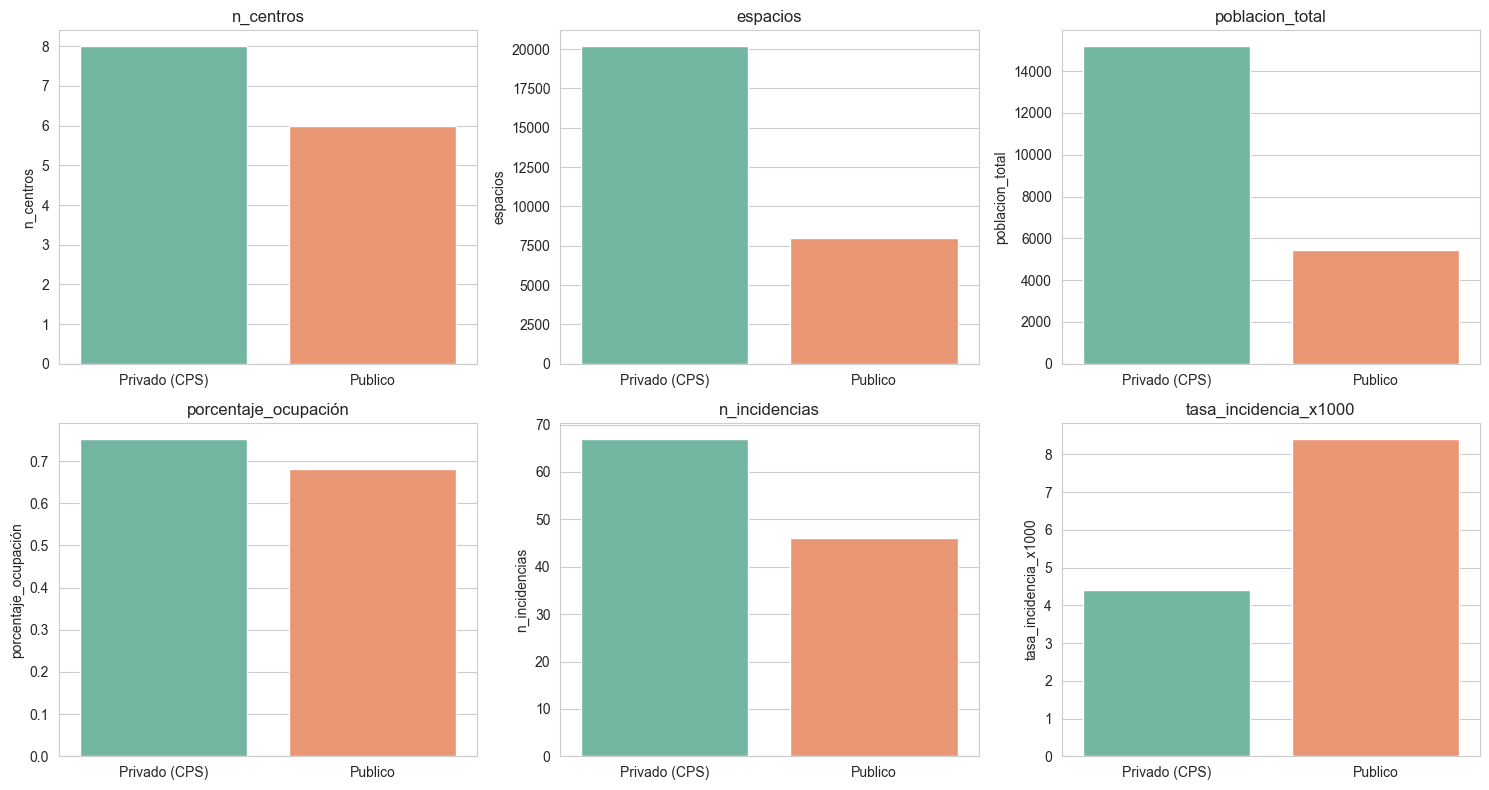

In [32]:
sns.set_style("whitegrid")
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
metrics = ['n_centros', 'espacios', 'poblacion_total', 
           'porcentaje_ocupación', 'n_incidencias', 'tasa_incidencia_x1000']

for ax, metric in zip(axes.flat, metrics):
    sns.barplot(data=federales, x='Tipo', y=metric, hue='Tipo', 
                ax=ax, palette='Set2', legend=False)
    ax.set_title(metric)
    ax.set_xlabel('')

plt.tight_layout()
plt.show()

### 2.2 Flujo de personas: ingresos y egresos

Se compara el total de ingresos y egresos de personas por tipo de centro.
Un diferencial positivo (más ingresos que egresos) indica crecimiento en la población interna.

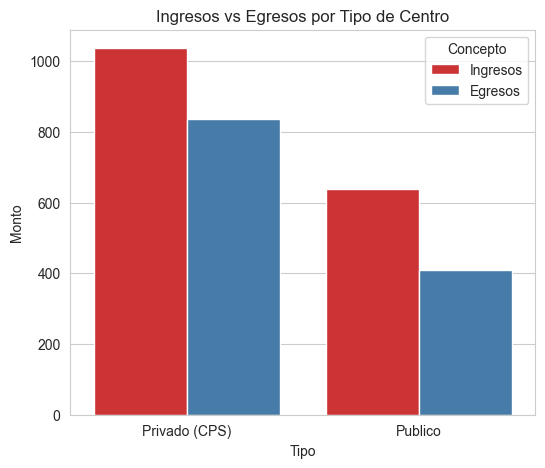

In [33]:
df_melt = federales.melt(id_vars='Tipo', value_vars=['Ingresos', 'Egresos'],
                   var_name='Concepto', value_name='Monto')

plt.figure(figsize=(6,5))
sns.barplot(data=df_melt, x='Tipo', y='Monto', hue='Concepto', palette='Set1')
plt.title('Ingresos vs Egresos por Tipo de Centro')
plt.show()

### 2.3 Incidencias por categoría

Se desglosan las incidencias según su tipo (riñas, autoagresiones, suicidios, etc.)
para identificar cuáles son más frecuentes y cuáles generan más personas involucradas o heridas.

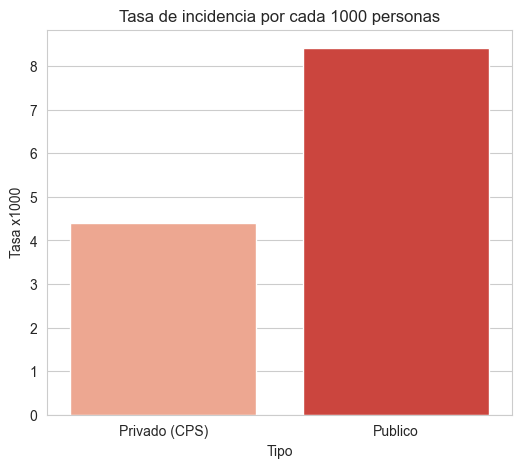

In [34]:
plt.figure(figsize=(6,5))
sns.barplot(data=federales, x='Tipo', y='tasa_incidencia_x1000', 
            hue='Tipo', palette='Reds', legend=False)
plt.title('Tasa de incidencia por cada 1000 personas')
plt.ylabel('Tasa x1000')
plt.show()

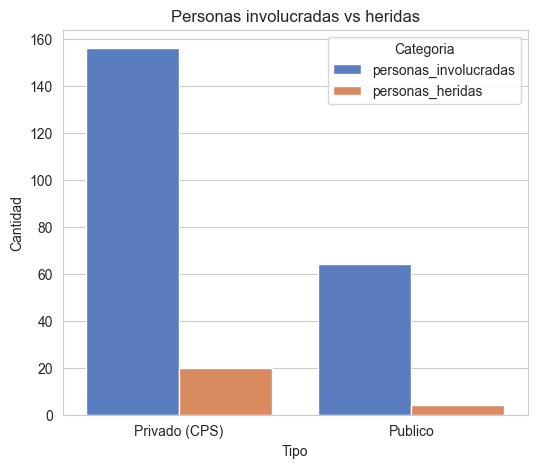

In [35]:
df_melt2 = federales.melt(id_vars='Tipo', 
                    value_vars=['personas_involucradas', 'personas_heridas'],
                    var_name='Categoria', value_name='Cantidad')

plt.figure(figsize=(6,5))
sns.barplot(data=df_melt2, x='Tipo', y='Cantidad', hue='Categoria', palette='muted')
plt.title('Personas involucradas vs heridas')
plt.show()

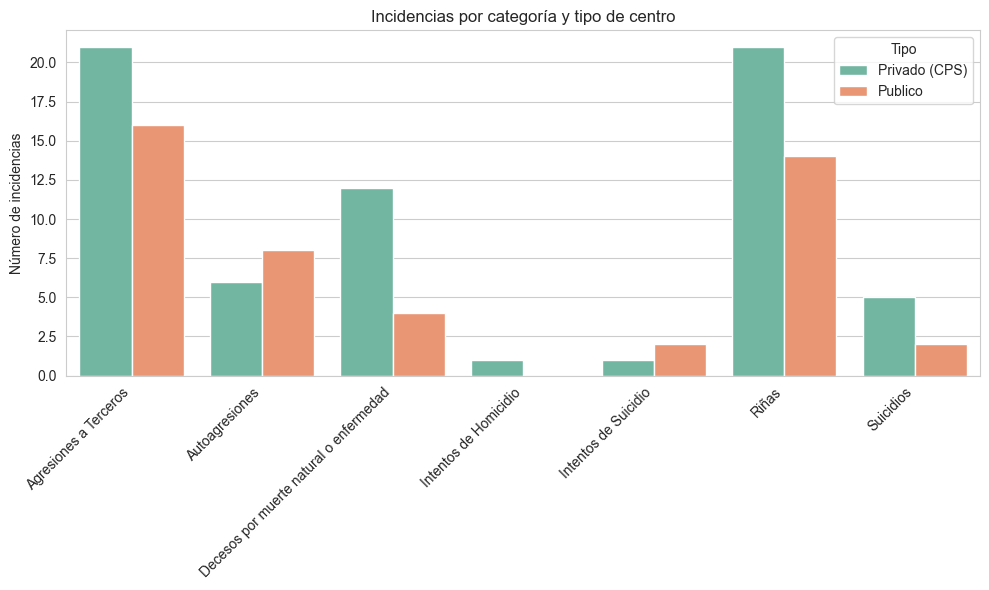

In [36]:
plt.figure(figsize=(10,6))
sns.barplot(data=tipo_incidencias, x='incidencia', y='incidencias', 
            hue='tipo', palette='Set2')
plt.title('Incidencias por categoría y tipo de centro')
plt.xlabel('')
plt.ylabel('Número de incidencias')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Tipo')
plt.tight_layout()
plt.show()

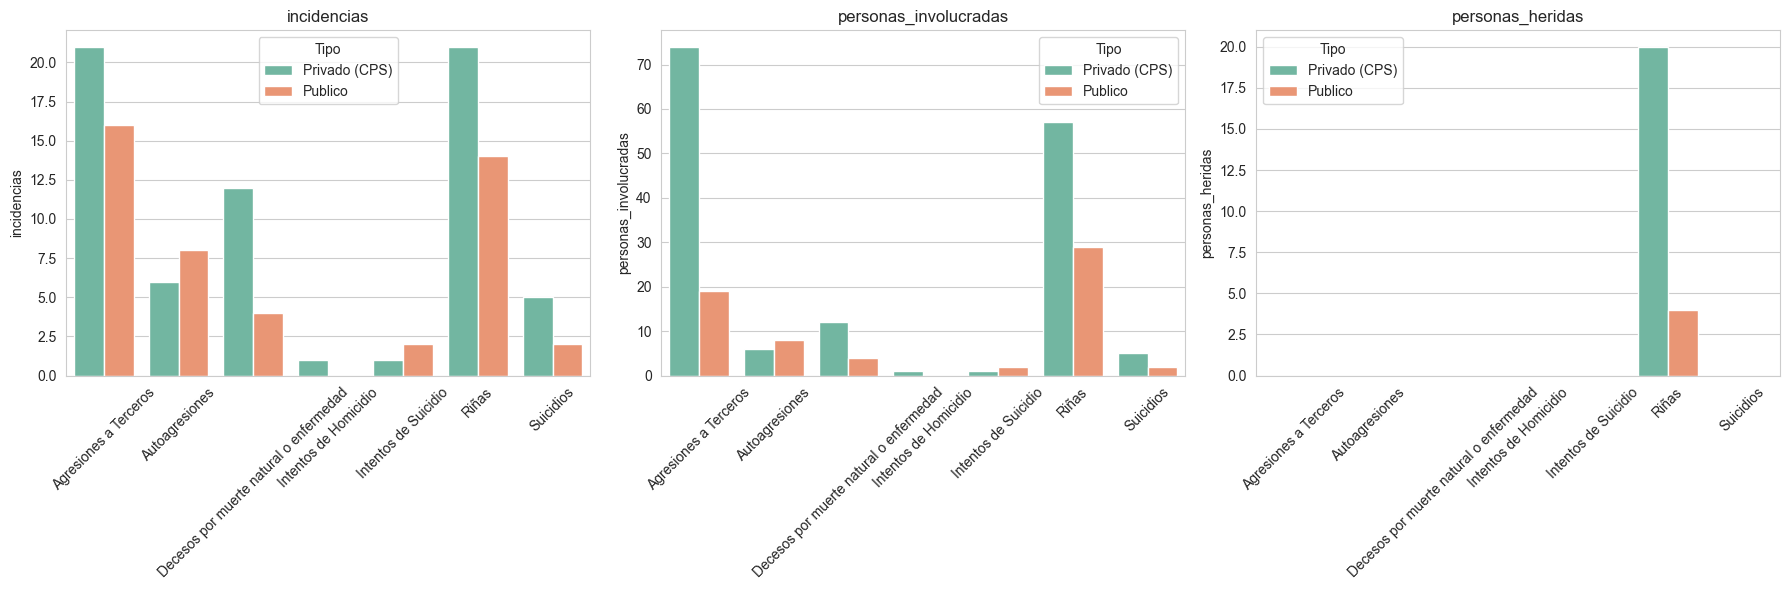

In [37]:
fig, axes = plt.subplots(1, 3, figsize=(18,6))
metrics = ['incidencias', 'personas_involucradas', 'personas_heridas']

for ax, metric in zip(axes, metrics):
    sns.barplot(data=tipo_incidencias, x='incidencia', y=metric, 
                hue='tipo', ax=ax, palette='Set2')
    ax.set_title(metric)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=45)
    ax.legend(title='Tipo')

plt.tight_layout()
plt.show()

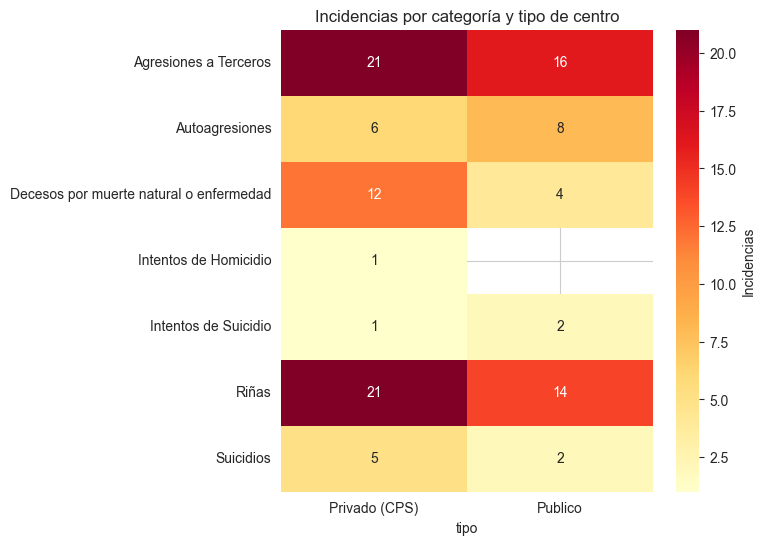

In [38]:
pivot = tipo_incidencias.pivot(index='incidencia', columns='tipo', values='incidencias')

plt.figure(figsize=(6,6))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlOrRd', cbar_kws={'label': 'Incidencias'})
plt.title('Incidencias por categoría y tipo de centro')
plt.ylabel('')
plt.show()

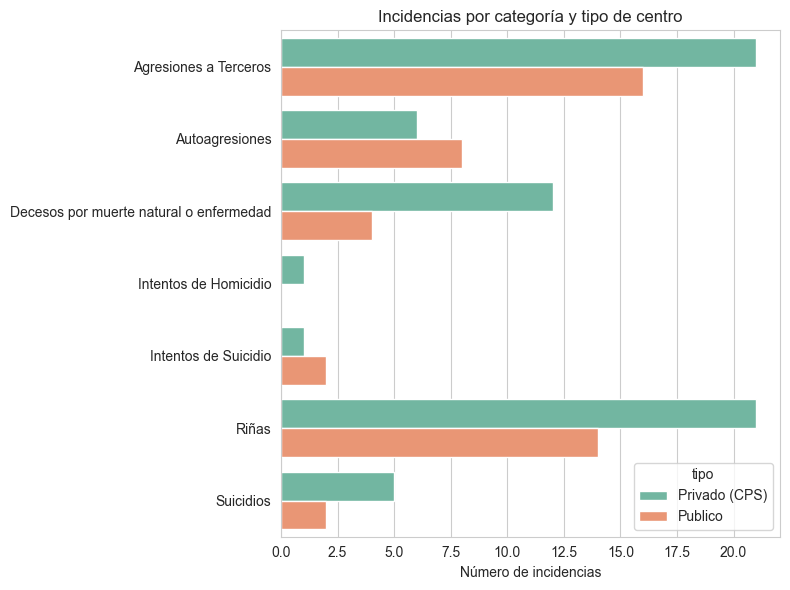

In [39]:
plt.figure(figsize=(8,6))
sns.barplot(data=tipo_incidencias, y='incidencia', x='incidencias', 
            hue='tipo', palette='Set2')
plt.title('Incidencias por categoría y tipo de centro')
plt.ylabel('')
plt.xlabel('Número de incidencias')
plt.tight_layout()
plt.show()

### 2.4 Incidencias normalizadas

Para comparar de forma justa entre centros Privados y Públicos (que tienen poblaciones
muy distintas), se presentan dos normalizaciones:

- **% dentro del tipo:** qué proporción representa cada categoría del total de incidencias de ese tipo
- **Tasa x1000 habitantes:** incidencias por cada 1,000 personas en la población de ese tipo, solo con fines normalizadores.

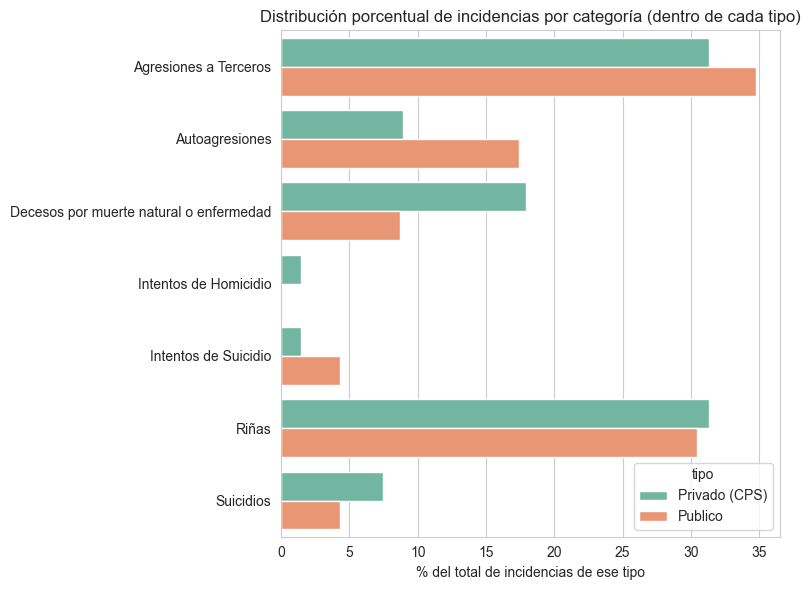

In [40]:
tipo_incidencias['pct_dentro_tipo'] = (
    tipo_incidencias['incidencias'] / 
    tipo_incidencias.groupby('tipo')['incidencias'].transform('sum') * 100
)

plt.figure(figsize=(8,6))
sns.barplot(data=tipo_incidencias, y='incidencia', x='pct_dentro_tipo', 
            hue='tipo', palette='Set2')
plt.title('Distribución porcentual de incidencias por categoría (dentro de cada tipo)')
plt.xlabel('% del total de incidencias de ese tipo')
plt.ylabel('')
plt.tight_layout()
plt.show()

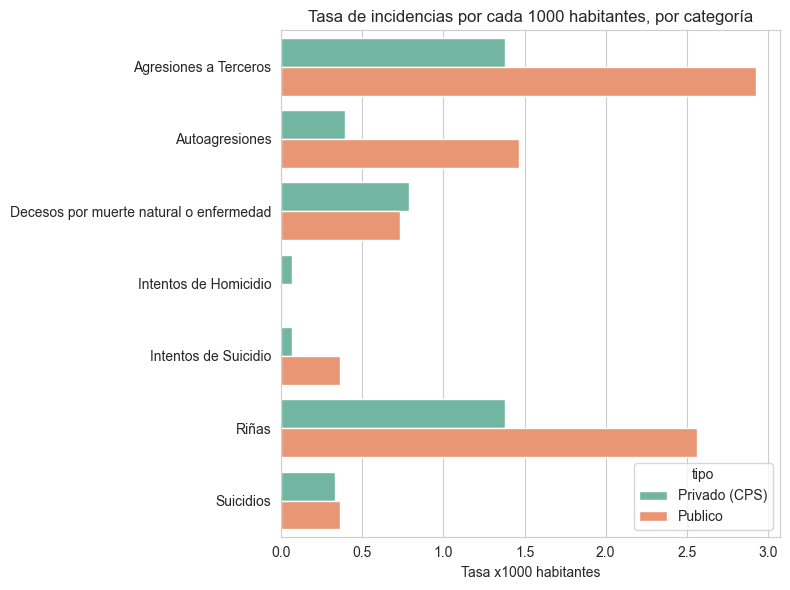

In [41]:
poblacion = federales.set_index('Tipo')['poblacion_total'].to_dict()

tipo_incidencias['poblacion_total'] = tipo_incidencias['tipo'].map(poblacion)
tipo_incidencias['tasa_x1000'] = (tipo_incidencias['incidencias'] / tipo_incidencias['poblacion_total']) * 1000

plt.figure(figsize=(8,6))
sns.barplot(data=tipo_incidencias, y='incidencia', x='tasa_x1000', 
            hue='tipo', palette='Set2')
plt.title('Tasa de incidencias por cada 1000 habitantes, por categoría')
plt.xlabel('Tasa x1000 habitantes')
plt.ylabel('')
plt.tight_layout()
plt.show()

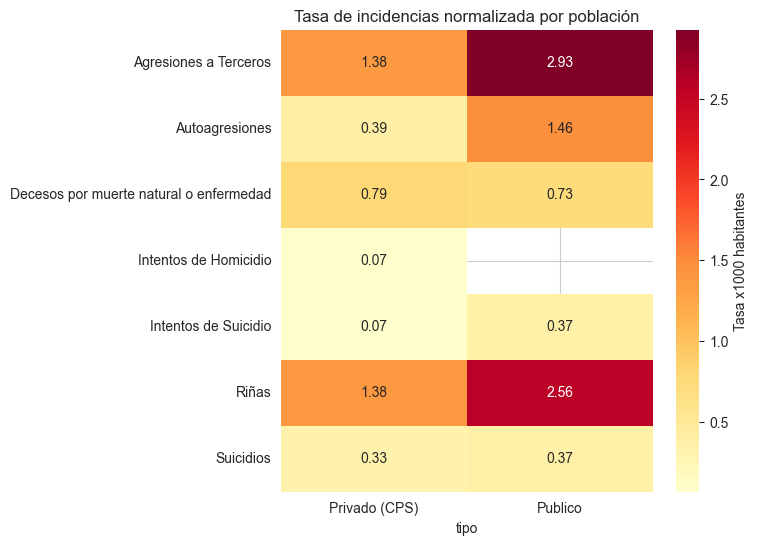

In [42]:
pivot_tasa = tipo_incidencias.pivot(index='incidencia', columns='tipo', values='tasa_x1000')

plt.figure(figsize=(6,6))
sns.heatmap(pivot_tasa, annot=True, fmt='.2f', cmap='YlOrRd', 
            cbar_kws={'label': 'Tasa x1000 habitantes'})
plt.title('Tasa de incidencias normalizada por población')
plt.ylabel('')
plt.show()

### 2.5 Escolaridad de la población interna

Se transforma el DataFrame de escolaridad a formato largo (melt) para facilitar
la visualización. Los valores se normalizan a porcentaje dentro de cada tipo de centro,
ya que Privado (CPS) tiene una población mayor en términos absolutos.

In [43]:
niveles_orden = [
    'no_sabe_leer_escribir', 'sabe_leer_escribir', 
    'primaria_incompleta', 'primaria_completa',
    'secundaria_incompleta', 'secundaria_completa',
    'bachillerato_incompleto', 'bachillerato_completo',
    'carrera_tecnica_incompleta', 'carrera_tecnica_completa',
    'licenciatura_incompleta', 'licenciatura_completa',
    'maestria_incompleta', 'maestria_completa',
    'doctorado_incompleto', 'doctorado_completo'
]

educacion_long = escolaridad_federal.melt(id_vars='Tipo', value_vars=niveles_orden,
                                  var_name='nivel', value_name='personas')

In [44]:
educacion_long['nivel'] = pd.Categorical(educacion_long['nivel'], 
                                          categories=niveles_orden, ordered=True)
educacion_long

,Tipo,nivel,personas
0,Privado (CPS),no_sabe_leer_escribir,137.25
1,Publico,no_sabe_leer_escribir,29.00
2,Privado (CPS),sabe_leer_escribir,1053.50
3,Publico,sabe_leer_escribir,78.50
4,Privado (CPS),primaria_incompleta,798.75
5,Publico,primaria_incompleta,389.50
6,Privado (CPS),primaria_completa,1552.25
7,Publico,primaria_completa,478.75
8,Privado (CPS),secundaria_incompleta,1280.00
9,Publico,secundaria_incompleta,464.25


In [45]:
educacion_long['pct'] = (
    educacion_long['personas'] / 
    educacion_long.groupby('Tipo')['personas'].transform('sum') * 100
)
educacion_long

,Tipo,nivel,personas,pct
0,Privado (CPS),no_sabe_leer_escribir,137.25,0.903421
1,Publico,no_sabe_leer_escribir,29.00,0.530553
2,Privado (CPS),sabe_leer_escribir,1053.50,6.934457
3,Publico,sabe_leer_escribir,78.50,1.436151
4,Privado (CPS),primaria_incompleta,798.75,5.257615
5,Publico,primaria_incompleta,389.50,7.125869
6,Privado (CPS),primaria_completa,1552.25,10.217381
7,Publico,primaria_completa,478.75,8.758690
8,Privado (CPS),secundaria_incompleta,1280.00,8.425348
9,Publico,secundaria_incompleta,464.25,8.493414


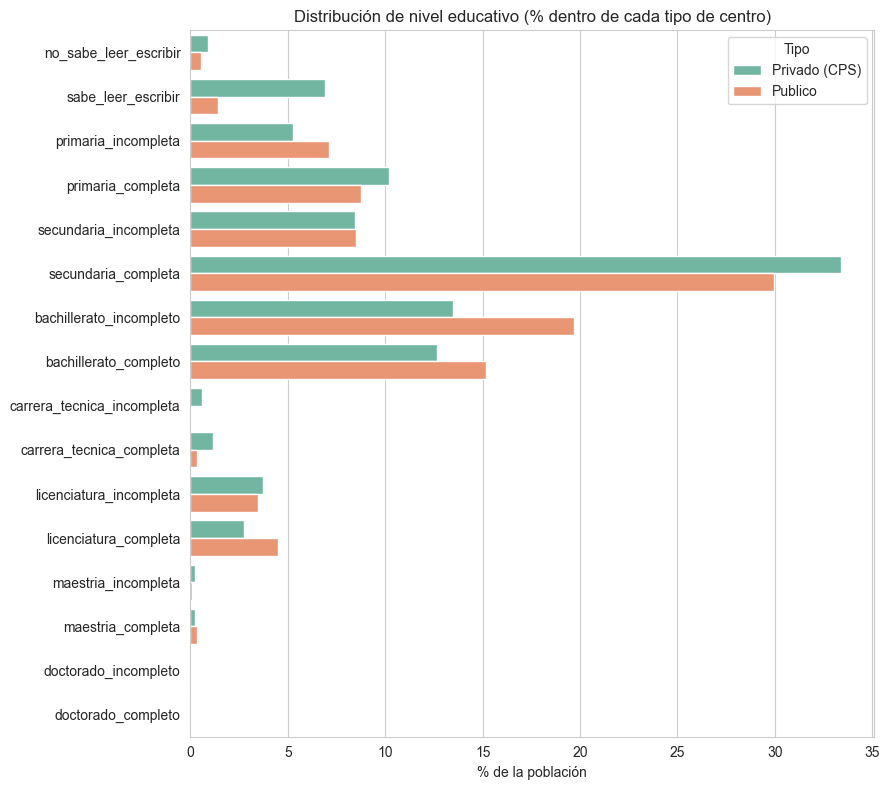

In [46]:
plt.figure(figsize=(9,8))
sns.barplot(data=educacion_long, y='nivel', x='pct', hue='Tipo', palette='Set2')
plt.title('Distribución de nivel educativo (% dentro de cada tipo de centro)')
plt.xlabel('% de la población')
plt.ylabel('')
plt.legend(title='Tipo')
plt.tight_layout()
plt.show()

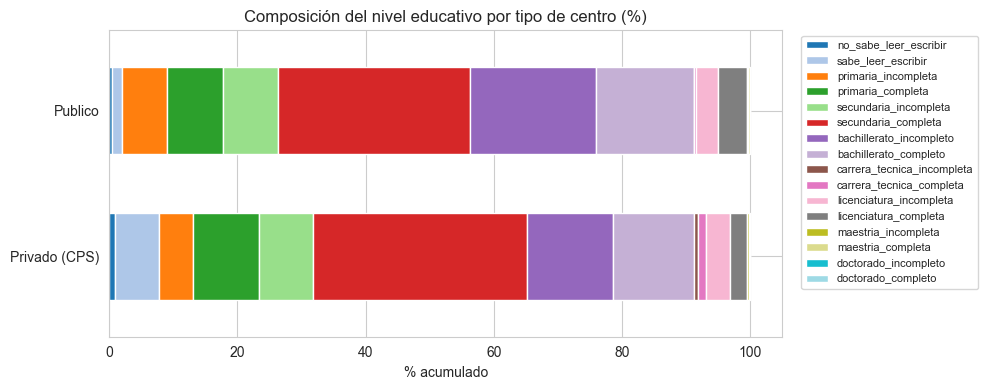

In [47]:
pivot_pct = educacion_long.pivot(index='Tipo', columns='nivel', values='pct')
pivot_pct = pivot_pct[niveles_orden]  # mantener el orden educativo

pivot_pct.plot(kind='barh', stacked=True, figsize=(10,4), 
               colormap='tab20', width=0.6)
plt.title('Composición del nivel educativo por tipo de centro (%)')
plt.xlabel('% acumulado')
plt.ylabel('')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

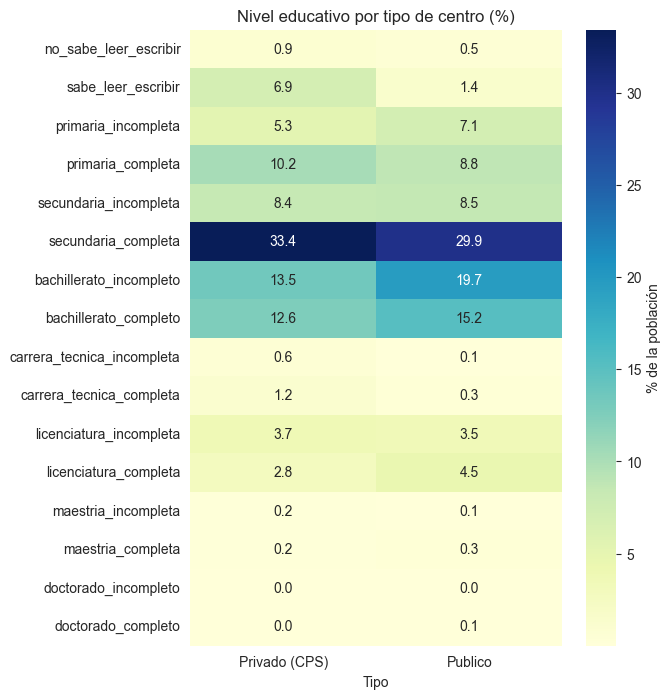

In [48]:
pivot = educacion_long.pivot(index='nivel', columns='Tipo', values='pct')
pivot = pivot.reindex(niveles_orden)

plt.figure(figsize=(6,8))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='YlGnBu', 
            cbar_kws={'label': '% de la población'})
plt.title('Nivel educativo por tipo de centro (%)')
plt.ylabel('')
plt.show()

### 2.6 Distribución por grupos de edad

Se analiza la composición etaria de la población interna por tipo de centro.
Los valores se normalizan a porcentaje para comparar la **forma** de la distribución,
independientemente del tamaño total de cada tipo.

Se presentan tres vistas: barras agrupadas, líneas de tendencia y pirámide comparativa.

In [49]:
grupos_edad = ['18-24', '25-29', '30-34', '35-39', '40-44', 
               '45-49', '50-54', '55-59', '60+']

edad_long = edades_federales.melt(id_vars='Tipo', value_vars=grupos_edad,
                       var_name='grupo_edad', value_name='personas')

edad_long['grupo_edad'] = pd.Categorical(edad_long['grupo_edad'], 
                                          categories=grupos_edad, ordered=True)
edad_long

,Tipo,grupo_edad,personas
0,Privado (CPS),18-24,911.75
1,Publico,18-24,273.25
2,Privado (CPS),25-29,1760.25
3,Publico,25-29,541.75
4,Privado (CPS),30-34,2851.50
5,Publico,30-34,1029.00
6,Privado (CPS),35-39,3028.25
7,Publico,35-39,1021.75
8,Privado (CPS),40-44,2539.25
9,Publico,40-44,882.00


In [50]:
edad_long['pct'] = (
    edad_long['personas'] / 
    edad_long.groupby('Tipo')['personas'].transform('sum') * 100
)
edad_long

,Tipo,grupo_edad,personas,pct
0,Privado (CPS),18-24,911.75,6.001415
1,Publico,18-24,273.25,4.999085
2,Privado (CPS),25-29,1760.25,11.586500
3,Publico,25-29,541.75,9.911270
4,Privado (CPS),30-34,2851.50,18.769438
5,Publico,30-34,1029.00,18.825467
6,Privado (CPS),35-39,3028.25,19.932861
7,Publico,35-39,1021.75,18.692828
8,Privado (CPS),40-44,2539.25,16.714114
9,Publico,40-44,882.00,16.136114


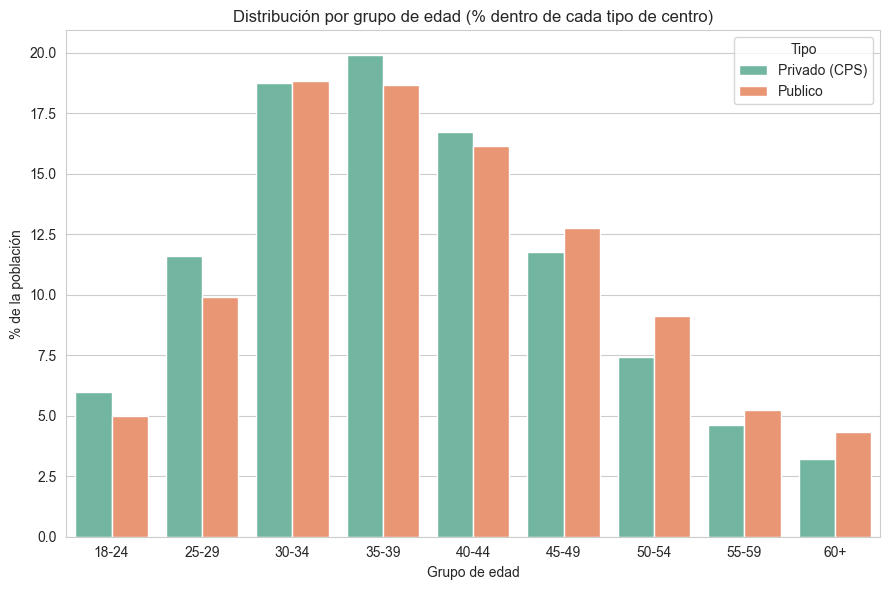

In [51]:
plt.figure(figsize=(9,6))
sns.barplot(data=edad_long, x='grupo_edad', y='pct', hue='Tipo', palette='Set2')
plt.title('Distribución por grupo de edad (% dentro de cada tipo de centro)')
plt.xlabel('Grupo de edad')
plt.ylabel('% de la población')
plt.legend(title='Tipo')
plt.tight_layout()
plt.show()

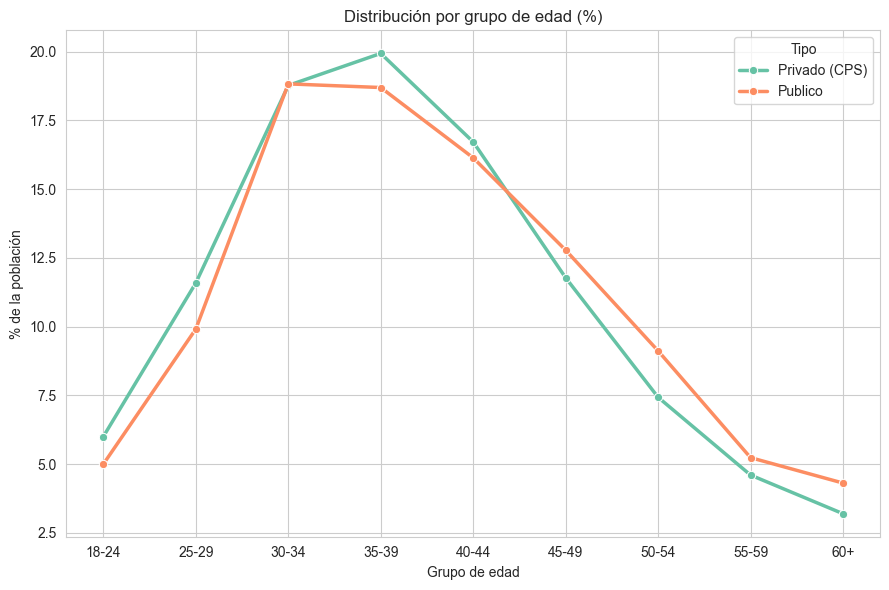

In [52]:
plt.figure(figsize=(9,6))
sns.lineplot(data=edad_long, x='grupo_edad', y='pct', hue='Tipo', 
             marker='o', palette='Set2', linewidth=2.5)
plt.title('Distribución por grupo de edad (%)')
plt.xlabel('Grupo de edad')
plt.ylabel('% de la población')
plt.legend(title='Tipo')
plt.tight_layout()
plt.show()

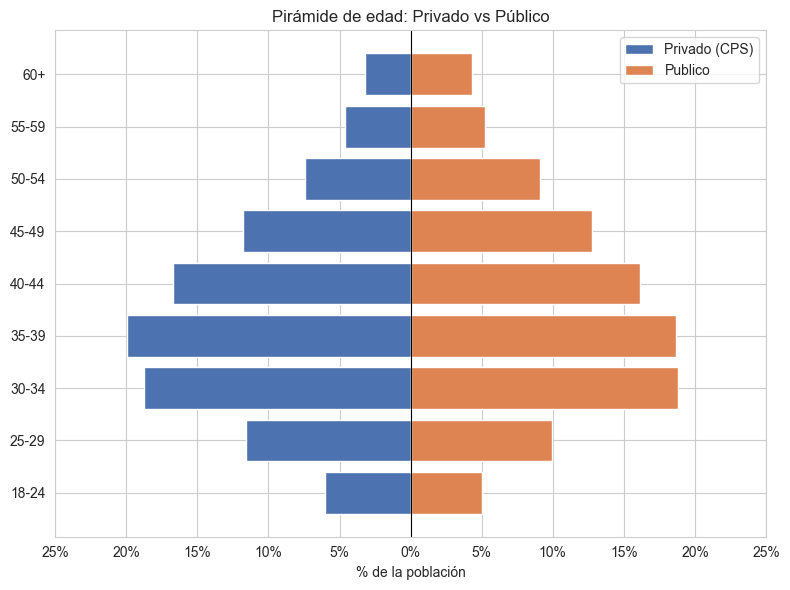

In [53]:
edad_pivot = edades_federales.set_index('Tipo')[grupos_edad]

# Normalizar cada fila a %
edad_pct = edad_pivot.div(edad_pivot.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(8,6))
y_pos = range(len(grupos_edad))

ax.barh(y_pos, -edad_pct.loc['Privado (CPS)'], color='#4C72B0', label='Privado (CPS)')
ax.barh(y_pos, edad_pct.loc['Publico'], color='#DD8452', label='Publico')

ax.set_yticks(y_pos)
ax.set_yticklabels(grupos_edad)
ax.set_xlabel('% de la población')
ax.set_title('Pirámide de edad: Privado vs Público')
ax.axvline(0, color='black', linewidth=0.8)

# Etiquetas del eje x como valores absolutos (sin el signo negativo)
xticks = ax.get_xticks()
ax.set_xticks(xticks)
ax.set_xticklabels([f'{abs(x):.0f}%' for x in xticks])

ax.legend()
plt.tight_layout()
plt.show()